# Demand Forecasting - Model Training

Predicts product demand using price, discount, inventory level, promotion, competitor
pricing, and category. Detailed EDA is in analysis.ipynb. This notebook covers model
comparison, hyperparameter tuning, and exporting the final model for the Streamlit app.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle

RANDOM_STATE = 42

## Load Data

In [2]:
df = pd.read_csv("data/demand_forecasting.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## Feature Selection

Using the same six inputs the Streamlit app collects: Price, Discount, Inventory Level,
Promotion, Competitor Pricing, and Category. Target is Demand.

In [3]:
features = ["Price", "Discount", "Inventory Level", "Promotion", "Competitor Pricing", "Category"]
target = "Demand"

X = df[features].copy()
y = df[target].copy()

X.head()

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries


## Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((60800, 6), (15200, 6))

## Encode Category

Category is nominal (no natural order), so one-hot encoding is used instead of label
encoding, it's correct for every model in the comparison, not just tree-based ones.
The encoder is fit on the training set only, then used to transform both sets.

In [5]:
preprocessor = ColumnTransformer(
    transformers=[("category", OneHotEncoder(drop="first", sparse_output=False), ["Category"])],
    remainder="passthrough",
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
feature_names

array(['category__Category_Electronics', 'category__Category_Furniture',
       'category__Category_Groceries', 'category__Category_Toys',
       'remainder__Price', 'remainder__Discount',
       'remainder__Inventory Level', 'remainder__Promotion',
       'remainder__Competitor Pricing'], dtype=object)

## Model Comparison

Fit several regression models and compare their test set performance before choosing
one to tune further.

In [7]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [8]:
models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(random_state=RANDOM_STATE))]),
    "Lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(random_state=RANDOM_STATE))]),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE),
}

model_list = []
mae_list = []
rmse_list = []
r2_list = []

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    y_test_pred = model.predict(X_test_enc)

    mae, rmse, r2 = evaluate_model(y_test, y_test_pred)

    print(name)
    print("- MAE: {:.2f}".format(mae))
    print("- RMSE: {:.2f}".format(rmse))
    print("- R2: {:.3f}".format(r2))
    print("--------------------------------")

    model_list.append(name)
    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)

Linear Regression
- MAE: 30.71
- RMSE: 39.17
- R2: 0.305
--------------------------------
Ridge
- MAE: 30.71
- RMSE: 39.17
- R2: 0.305
--------------------------------
Lasso
- MAE: 30.87
- RMSE: 39.35
- R2: 0.299
--------------------------------
Decision Tree
- MAE: 35.95
- RMSE: 50.31
- R2: -0.146
--------------------------------
Random Forest
- MAE: 27.31
- RMSE: 36.79
- R2: 0.387
--------------------------------
XGBoost
- MAE: 27.15
- RMSE: 35.73
- R2: 0.422
--------------------------------


In [9]:
results = pd.DataFrame({
    "Model": model_list,
    "MAE": mae_list,
    "RMSE": rmse_list,
    "R2": r2_list,
}).sort_values(by="RMSE")

results

,Model,MAE,RMSE,R2
5,XGBoost,27.153584,35.730093,0.421947
4,Random Forest,27.307686,36.793277,0.387034
0,Linear Regression,30.708564,39.166676,0.305403
1,Ridge,30.708573,39.166682,0.305403
2,Lasso,30.873594,39.352752,0.298787
3,Decision Tree,35.947895,50.308331,-0.145986


Random Forest and XGBoost clearly outperform the linear models and the single
decision tree, so these two are carried forward for hyperparameter tuning.

## Hyperparameter Tuning

In [10]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 10, 12, 15],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

xgb_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

In [11]:
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=rf_params,
    n_iter=25,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train_enc, y_train)

print("Best Random Forest params:", rf_search.best_params_)

Best Random Forest params: {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 15}


In [12]:
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=xgb_params,
    n_iter=25,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_search.fit(X_train_enc, y_train)

print("Best XGBoost params:", xgb_search.best_params_)

Best XGBoost params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


## Test Set Performance (Tuned Models)

In [13]:
rf_model = rf_search.best_estimator_
xgb_model = xgb_search.best_estimator_

rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, rf_model.predict(X_test_enc))
xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(y_test, xgb_model.predict(X_test_enc))

print("Random Forest (tuned)")
print("- MAE: {:.2f}".format(rf_mae))
print("- RMSE: {:.2f}".format(rf_rmse))
print("- R2: {:.3f}".format(rf_r2))
print("--------------------------------")
print("XGBoost (tuned)")
print("- MAE: {:.2f}".format(xgb_mae))
print("- RMSE: {:.2f}".format(xgb_rmse))
print("- R2: {:.3f}".format(xgb_r2))

Random Forest (tuned)
- MAE: 26.85
- RMSE: 35.40
- R2: 0.432
--------------------------------
XGBoost (tuned)
- MAE: 27.31
- RMSE: 35.72
- R2: 0.422


## Final Model Selection

Random Forest scores marginally better than XGBoost, but the difference is small
(under 1% on RMSE) and not something a user of the app would notice. The tuned Random
Forest also saves to a file well over 100 MB because of its depth and number of trees,
while the tuned XGBoost model saves to only a few MB. Since the accuracy gap is
negligible but the file size gap is large, XGBoost is the better choice for a model
that has to be deployed alongside a Streamlit app in a GitHub repo. XGBoost is used as
the final model.

In [14]:
best_model = xgb_model
print("Final model: XGBoost")

Final model: XGBoost


## Feature Importance

In [15]:
importance = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False)
importance

category__Category_Furniture      0.348244
remainder__Promotion              0.301724
category__Category_Groceries      0.150021
category__Category_Electronics    0.065220
category__Category_Toys           0.049067
remainder__Price                  0.042224
remainder__Discount               0.017867
remainder__Competitor Pricing     0.015756
remainder__Inventory Level        0.009877
dtype: float32

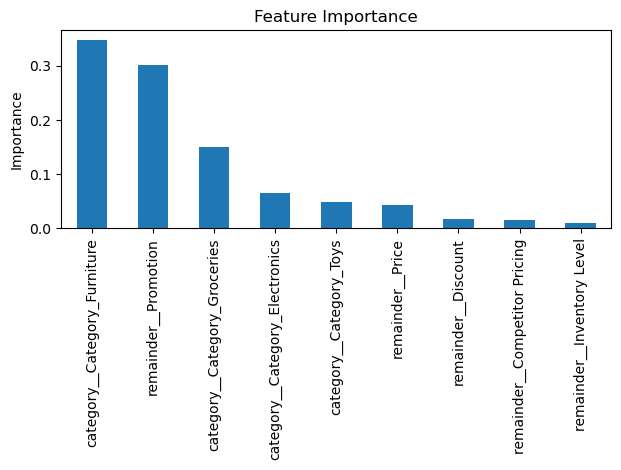

In [16]:
importance.plot(kind="bar", title="Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Save Model

In [17]:
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

with open("xgboost_demand_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Saved preprocessor.pkl and xgboost_demand_model.pkl")

Saved preprocessor.pkl and xgboost_demand_model.pkl
